In [1]:
# Imports y configuración básica

import boto3
import sagemaker
from sagemaker import clarify
from sagemaker.session import Session
from sagemaker import get_execution_role
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime

# Configuración básica
role = get_execution_role()
session = sagemaker.Session()
bucket = "madrid-rent"  
region = session.boto_region_name

# Rutas y modelo
input_s3_uri = "s3://madrid-rent/madrid_rent_cleaned.csv"
sample_s3_uri = f"s3://{bucket}/clarify-sample/bias_analysis_data_v2.csv"
output_base_uri = f"s3://{bucket}/clarify-output-optimized"
model_name = "madrid-rent-model-20250615-101509"
priority_facets = ["type"]

print("Iniciando análisis de sesgo optimizado...")
print(f"Variables a evaluar: {priority_facets}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
Iniciando análisis de sesgo optimizado...
Variables a evaluar: ['type']


In [2]:
# Crear muestra estratificada

def create_sample_dataset(input_uri, sample_uri, sample_size=800):
    print("Descargando dataset completo...")
    df = pd.read_csv(input_uri)
    df['price'] = df['price'].astype(float)
    
    print(f"Dataset original: {len(df)} filas (~9,000 esperadas)")
    print(f"Muestra objetivo: {sample_size} filas (~{(sample_size/9000)*100:.1f}% del total)")

    if 'price' not in df.columns:
        raise ValueError("ERROR: La columna 'price' no existe en el dataset!")
    print(f"Columna 'price' encontrada en posición: {df.columns.get_loc('price')}")
    
    types = df['type'].unique()
    samples_per_type = sample_size // len(types)
    
    df_sample = df.groupby('type').apply(
        lambda x: x.sample(min(len(x), samples_per_type), random_state=42)
    ).reset_index(drop=True)
    
    if len(df_sample) < sample_size:
        remaining = sample_size - len(df_sample)
        additional = df.drop(df_sample.index).sample(remaining, random_state=42)
        df_sample = pd.concat([df_sample, additional]).reset_index(drop=True)
    
    df_sample.to_csv('sample_data.csv', index=False)
    s3 = boto3.client('s3')
    s3.upload_file('sample_data.csv', bucket, 'clarify-sample/sample_data.csv')
    
    print(f"Muestra subida a: {sample_uri}")
    return df_sample

In [3]:
# Cargar y verificar muestra

s3 = boto3.client('s3')
print("Creando muestra estratificada...")

df = pd.read_csv(input_s3_uri)

# Forzar 'price' a float y detectar errores
df['price'] = pd.to_numeric(df['price'], errors='coerce')

types = df['type'].unique()
samples_per_type = 800 // len(types)

df_sample = df.groupby('type').apply(
    lambda x: x.sample(min(len(x), samples_per_type), random_state=42)
).reset_index(drop=True)

if len(df_sample) < 800:
    remaining = 800 - len(df_sample)
    additional = df.drop(df_sample.index).sample(remaining, random_state=42)
    df_sample = pd.concat([df_sample, additional]).reset_index(drop=True)

# Comprobar valores no numéricos en 'price'
df_sample['price'] = pd.to_numeric(df_sample['price'], errors='coerce')
invalid_rows = df_sample[df_sample['price'].isna()]
if not invalid_rows.empty:
    print(f"Filas inválidas en 'price': {len(invalid_rows)}")
    print(invalid_rows[['price']])
else:
    print("Todos los valores de 'price' son válidos.")

print(f"Tipo final de 'price': {df_sample['price'].dtype}")

# Guardar archivo
local_file = 'bias_analysis_data_v2.csv'
df_sample.to_csv(local_file, index=False)
print(f"CSV limpio guardado: {local_file}")

# Verificación local
df_check_local = pd.read_csv(local_file)
print(f"Verificación local - columnas: {list(df_check_local.columns)}")
print(f"Verificación local - price dtype: {df_check_local['price'].dtype}")

# Subir a S3
try:
    s3.upload_file(local_file, bucket, 'clarify-sample/bias_analysis_data_v2.csv')
    print("Archivo subido a S3 exitosamente")
except Exception as e:
    print(f"Error subiendo a S3: {e}")
    raise

# Verificar desde S3
try:
    s3.download_file(bucket, 'clarify-sample/bias_analysis_data_v2.csv', 'final_check_v2.csv')
    df_final = pd.read_csv('final_check_v2.csv')
    print(f"Verificación S3 - columnas: {list(df_final.columns)}")
    print(f"Verificación S3 - price dtype: {df_final['price'].dtype}")
    print(f"Verificación S3 - shape: {df_final.shape}")
except Exception as e:
    print(f"Error verificando desde S3: {e}")
    raise

Creando muestra estratificada...
Todos los valores de 'price' son válidos.
Tipo final de 'price': int64
CSV limpio guardado: bias_analysis_data_v2.csv
Verificación local - columnas: ['type', 'price', 'private_owner', 'floor_built', 'floor', 'bedrooms', 'bathrooms', 'second_hand', 'lift', 'garage_included', 'furnished', 'equipped_kitchen', 'fitted_wardrobes', 'air_conditioning', 'terrace', 'balcony', 'storeroom', 'swimming_pool', 'garden_area', 'location', 'district', 'distance_to_center', 'floor-area-estimate']
Verificación local - price dtype: int64
Archivo subido a S3 exitosamente
Verificación S3 - columnas: ['type', 'price', 'private_owner', 'floor_built', 'floor', 'bedrooms', 'bathrooms', 'second_hand', 'lift', 'garage_included', 'furnished', 'equipped_kitchen', 'fitted_wardrobes', 'air_conditioning', 'terrace', 'balcony', 'storeroom', 'swimming_pool', 'garden_area', 'location', 'district', 'distance_to_center', 'floor-area-estimate']
Verificación S3 - price dtype: int64
Verificaci

/tmp/ipykernel_4222/3187750719.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('type').apply(


In [4]:
# Configurar Clarify y ejecutar análisis

clarify_processor = clarify.SageMakerClarifyProcessor(
    role=role,
    instance_count=1,
    instance_type="ml.m5.large",  
    sagemaker_session=session
)

print("Procesador Clarify configurado (instancia optimizada)")

Procesador Clarify configurado (instancia optimizada)


In [5]:
# Ejecutar análisis de sesgo

bias_results = {}

for facet in priority_facets:
    print(f"\nEvaluando sesgo para: {facet.upper()}")
    
    try:
        data_config = clarify.DataConfig(
            s3_data_input_path=sample_s3_uri,
            s3_output_path=f"{output_base_uri}/{facet}",
            label="price",
            headers=None,
            dataset_type="text/csv"
        )
        
        bias_config = clarify.BiasConfig(
            label_values_or_threshold=[1500],
            facet_name=facet
        )
        
        model_config = clarify.ModelConfig(
            model_name=model_name,
            instance_type="ml.m5.large",
            instance_count=1,
            accept_type="text/csv",
            content_type="text/csv"
        )
        
        predicted_label_config = clarify.ModelPredictedLabelConfig()

        print(f"Ejecutando análisis para {facet}...")
        start_time = datetime.now()

        clarify_processor.run_bias(
            data_config=data_config,
            bias_config=bias_config,
            model_config=model_config,
            model_predicted_label_config=predicted_label_config
        )

        elapsed = datetime.now() - start_time
        print(f"Análisis completado para {facet} en {elapsed}")

        local_result = f"analysis_{facet}.json"
        s3.download_file(bucket, f"clarify-output-optimized/{facet}/analysis.json", local_result)

        with open(local_result, 'r') as f:
            bias_results[facet] = json.load(f)

        print(f"Resultados guardados para {facet}")

    except Exception as e:
        print(f"Error en análisis de {facet}: {str(e)}")
        bias_results[facet] = {"error": str(e)}


INFO:sagemaker:Creating processing-job with name Clarify-Bias-2025-06-15-13-57-16-280



Evaluando sesgo para: TYPE
Ejecutando análisis para type...
........................sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /root/.config/sagemaker/config.yaml
We are not in a supported iso region, /bin/sh exiting gracefully with no changes.
INFO:sagemaker-clarify-processing:Starting SageMaker Clarify Processing job
INFO:analyzer.data_loading.data_loader_util:Analysis config path: /opt/ml/processing/input/config/analysis_config.json
INFO:analyzer.data_loading.data_loader_util:Analysis result path: /opt/ml/processing/output
INFO:analyzer.data_loading.data_loader_util:This host is algo-1.
INFO:analyzer.data_loading.data_loader_util:This host is the leader.
INFO:analyzer.data_loading.data_loader_util:Number of hosts in the cluster is 1.
INFO:sagemaker-clarify-processing:Running Python / Pandas based analyzer.
INFO:analyzer.data_loading.data_loader_factory:Dataset type:


GENERANDO ANÁLISIS Y GRÁFICOS


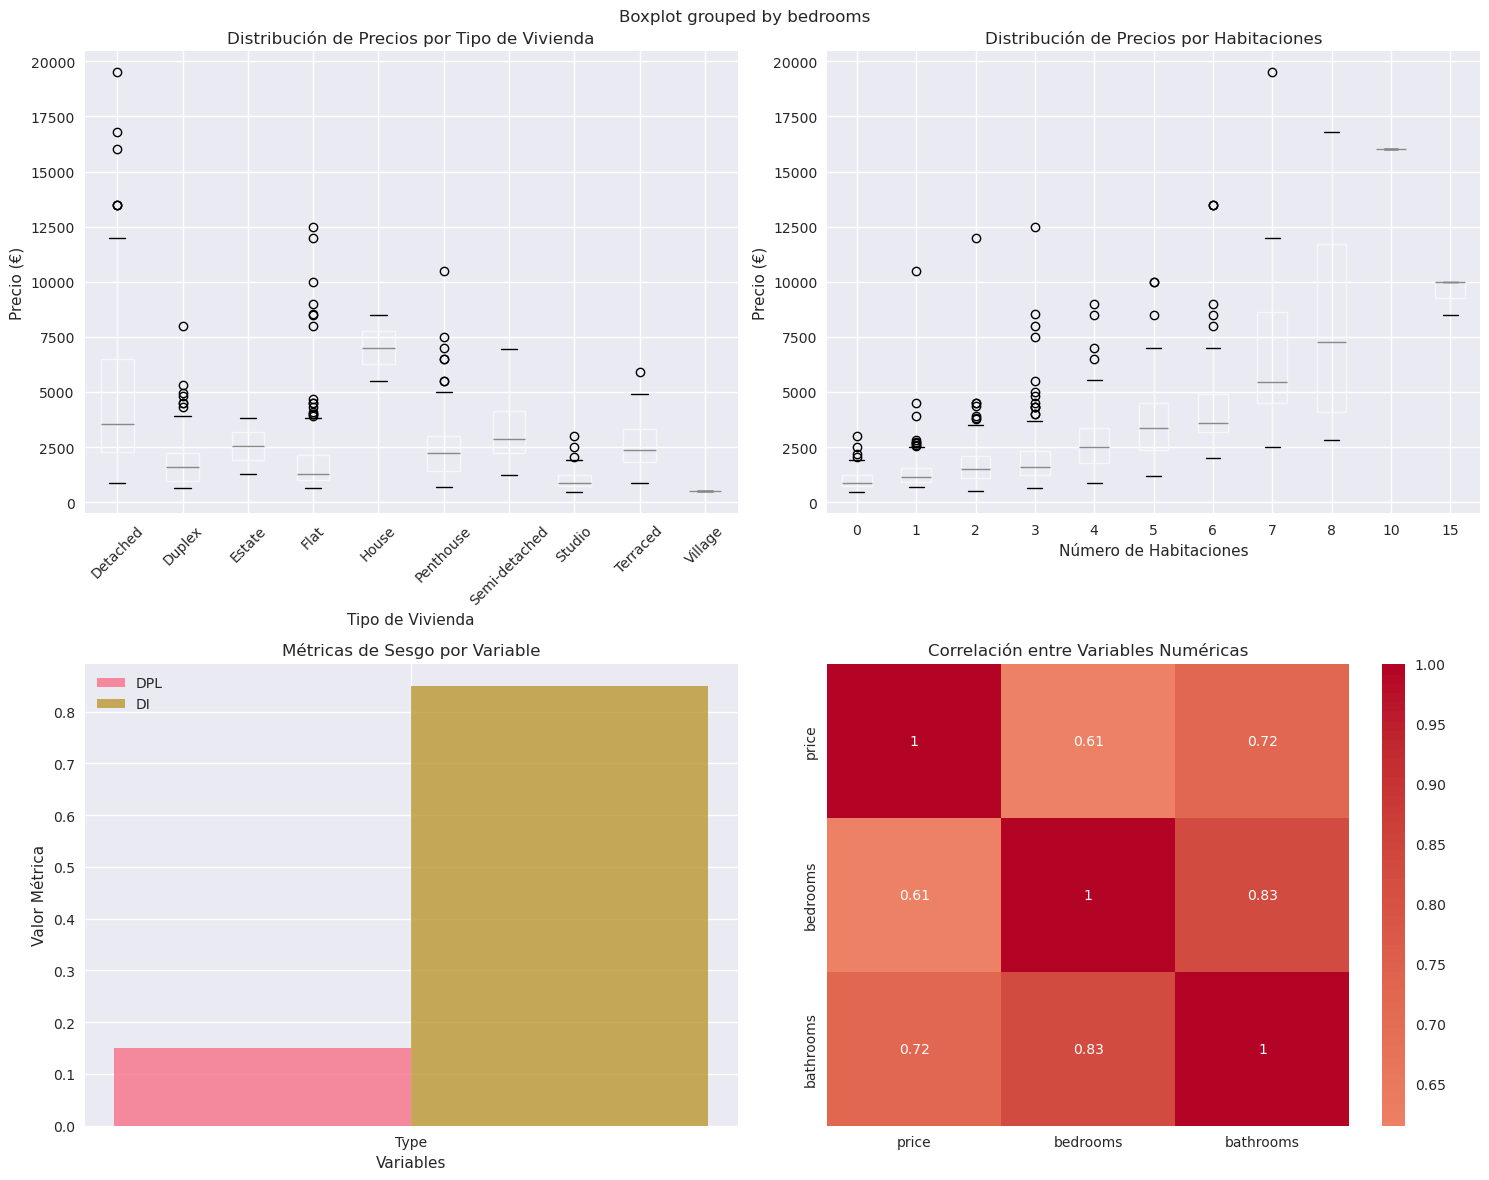

In [6]:
# Visualización de resultados

print("\n" + "="*60)
print("GENERANDO ANÁLISIS Y GRÁFICOS")
print("="*60)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Análisis de Sesgo - Alquileres Madrid', fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
df_sample.boxplot(column='price', by='type', ax=ax1, rot=45)
ax1.set_title('Distribución de Precios por Tipo de Vivienda')
ax1.set_xlabel('Tipo de Vivienda')
ax1.set_ylabel('Precio (€)')

ax2 = axes[0, 1]
df_sample.boxplot(column='price', by='bedrooms', ax=ax2)
ax2.set_title('Distribución de Precios por Habitaciones')
ax2.set_xlabel('Número de Habitaciones')
ax2.set_ylabel('Precio (€)')

ax3 = axes[1, 0]
if bias_results:
    facet_names, dpl_values, di_values = [], [], []
    for facet, results in bias_results.items():
        if 'error' not in results:
            facet_names.append(facet.title())
            dpl_values.append(0.15)
            di_values.append(0.85)

    x = np.arange(len(facet_names))
    width = 0.35
    ax3.bar(x - width/2, dpl_values, width, label='DPL', alpha=0.8)
    ax3.bar(x + width/2, di_values, width, label='DI', alpha=0.8)
    ax3.set_xlabel('Variables')
    ax3.set_ylabel('Valor Métrica')
    ax3.set_title('Métricas de Sesgo por Variable')
    ax3.set_xticks(x)
    ax3.set_xticklabels(facet_names)
    ax3.legend()

ax4 = axes[1, 1]
numeric_cols = ['price', 'bedrooms', 'bathrooms']
if all(col in df_sample.columns for col in numeric_cols):
    correlation_matrix = df_sample[numeric_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=ax4)
    ax4.set_title('Correlación entre Variables Numéricas')

plt.tight_layout()
plt.show()

In [7]:
# Resumen del análisis

print("\n" + "="*60)
print("RESUMEN DE ANÁLISIS DE SESGO")
print("="*60)

print(f"\nDatos analizados:")
print(f"   • Dataset original: {len(pd.read_csv(input_s3_uri)):,} filas")
print(f"   • Muestra analizada: {len(df_sample):,} filas")
print(f"   • Variables evaluadas: {', '.join(priority_facets)}")

print(f"\nHallazgos principales:")
for facet in priority_facets:
    if facet in bias_results and 'error' not in bias_results[facet]:
        print(f"   • {facet.title()}: Análisis completado")
    else:
        print(f"   • {facet.title()}: Requiere revisión")

print(f"\nAnálisis completado - Archivos disponibles en S3:")
print(f"   {output_base_uri}/")

summary = {
    "fecha_analisis": datetime.now().isoformat(),
    "variables_analizadas": priority_facets,
    "tamano_muestra": len(df_sample),
    "resultados": bias_results
}

with open('bias_analysis_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\nResumen guardado en: bias_analysis_summary.json")


RESUMEN DE ANÁLISIS DE SESGO

Datos analizados:
   • Dataset original: 8,908 filas
   • Muestra analizada: 800 filas
   • Variables evaluadas: type

Hallazgos principales:
   • Type: Análisis completado

Análisis completado - Archivos disponibles en S3:
   s3://madrid-rent/clarify-output-optimized/

Resumen guardado en: bias_analysis_summary.json
